_Células em Markdown foram traduzidas por mim, comentários originais foram feitos nas células de código._

# Lidando com _outliers_

Algumas vezes _outliers_ podem bagunçar a análise; Você geralmente não quer que alguns determinados dados inclinem (_skew_) o resultado ao todo. Vamos revisitar o exemplo de dados de receita e adicionar a receita de um bilionário.


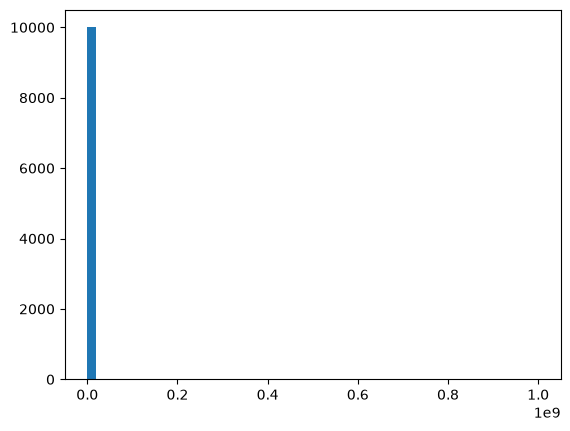

In [1]:
%matplotlib inline
import numpy as np

incomes = np.random.normal(27000, 15000, 10000)
incomes = np.append(incomes, [1000000000]) # Adiciona o _outlier_

import matplotlib.pyplot as plt
plt.hist(incomes, 50)
plt.show()

# Note que o histograma acaba empilando demais dados em uma barra só e o _outlier_ nem aparece no gráfico por se tratar
# de apenas um.

Visualizar esse gráfico não ajuda muito. 1 bilionário acaba espremendo os demais em uma só linha do histograma. 
Além de inclinar (_skew_) a receita média significativamente:

In [2]:
incomes.mean()

np.float64(126775.20596592722)

É importante investigar o que ocasiona os _outliers_, e entender de onde eles estão vindo. Você também deve 
pensar se remover eles é algo válido a se fazer, dado a motivação do que está tentando analisar. Se eu sei que eu quero entender mais sobre as receitas the "Americanos típicos", remover os bilionários parece ser algo legítimo a se fazer.

Aqui está algo um pouco mais robusto do que apenas remover os bilionários - Isto filtra qualquer dado além de dois desvios padrões da mediana no conjunto de dados:

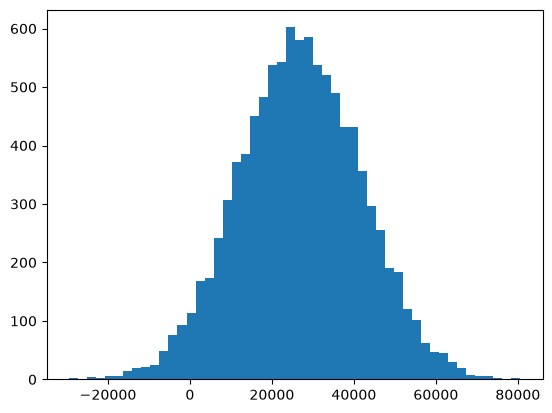

In [3]:
def reject_outliers(data):
    u = np.median(data) # Mediana
    s = np.std(data) # Desvio padrão
    filtered = [e for e in data if (u - 2 * s < e < u + 2 * s)] # Filtra os dados onde:
                                                                # u - 2 * s -> dessa forma remove dados que estão dois 
                                                                # desvios padrão antes da mediana. 
                                                                # u + 2 * s -> remove dados que estão dois desvios
                                                                # padrão após a mediana (que é o caso do bilionário)
    return filtered

filtered = reject_outliers(incomes)
plt.hist(filtered, 50)
plt.show() # mostra agora os dados eu uma normalização. Mais vísível o gráfico após a limpeza.

In [4]:
np.mean(filtered) # A média agora está mais representativa.

np.float64(26787.88348652382)

# Atividade

Ao invés de apenas um _outlier_, adiciona vários outliers gerados aleatoriamente nos dados. Experimente com diferentes valores de vários multiplos dos desvios padrões para identificar outliers, e veja que efeito isso tem no resultado final.

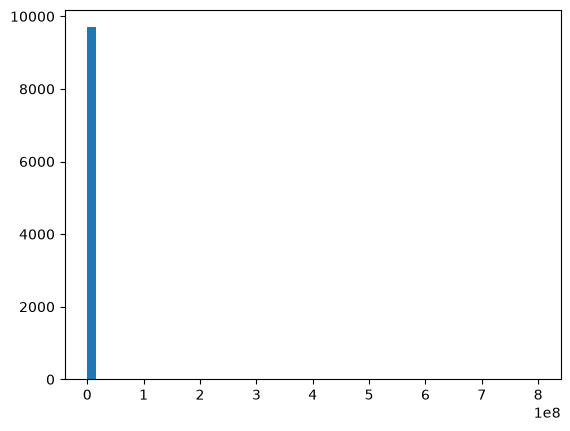

In [22]:
new_incomes = np.random.normal(27000, 15000, 10000)
new_incomes = new_incomes[new_incomes >= 0]

for i in range(50): # Adicionando _outliers_ abaixo 
    random_income = np.random.randint(5000, 15000)
    new_incomes = np.append(new_incomes, random_income)

# Adicionando _outliers_ acima 
new_incomes = np.append(new_incomes, [50000000, 700000000, 300000000, 800000000])

plt.hist(new_incomes, 50)
plt.show()

In [23]:
def show_with_reject_outliers(data, std_multiple=2): # Mostra o histograma com base no múltipo do desvio padrão informado,
                                                    # além de outras informações antes de limpar os dados.

    print(f'\nAntes de remover outliers')
    print(f'Média: {data.mean()}')
    print(f'Minímo: {data.min()}')
    print(f'Máximo: {data.max()}')
    
    u = np.median(data) # Mediana
    s = np.std(data) # Desvio padrão
    new_data = [e for e in data if (u - std_multiple * s < e < u + std_multiple * s)]

    print(f'\nApós de remover outliers')
    print(f'Média: {np.mean(new_data)}')
    print(f'Minímo: {np.min(new_data)}')
    print(f'Máximo: {np.max(new_data)}')
    
    plt.hist(new_data, 50)
    plt.show() # mostra agora os dados eu uma normalização. Mais vísível o gráfico após a limpeza.


Antes de remover outliers
Média: 218926.8864580367
Minímo: 48.41187391223678
Máximo: 800000000.0

Após de remover outliers
Média: 28236.539706034226
Minímo: 48.41187391223678
Máximo: 85818.99208018096


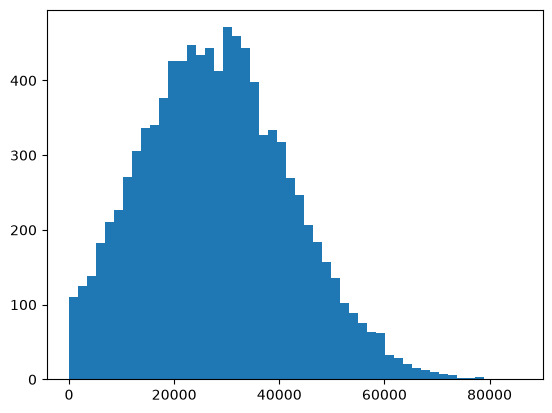

In [24]:
show_with_reject_outliers(new_incomes, std_multiple=1)


Antes de remover outliers
Média: 218926.8864580367
Minímo: 48.41187391223678
Máximo: 800000000.0

Após de remover outliers
Média: 28236.539706034226
Minímo: 48.41187391223678
Máximo: 85818.99208018096


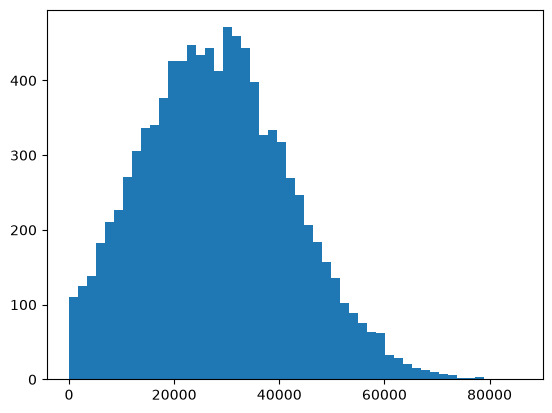

In [25]:
show_with_reject_outliers(new_incomes, std_multiple=2)


Antes de remover outliers
Média: 218926.8864580367
Minímo: 48.41187391223678
Máximo: 800000000.0

Após de remover outliers
Média: 28236.539706034226
Minímo: 48.41187391223678
Máximo: 85818.99208018096


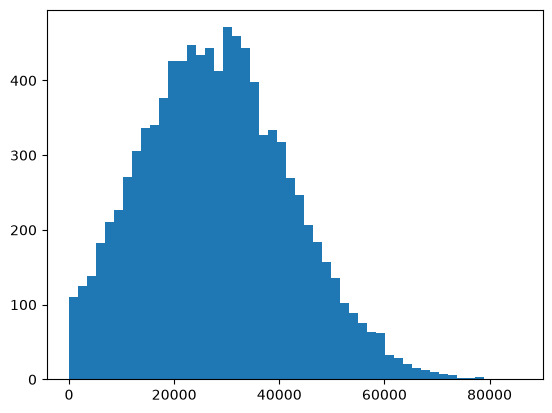

In [26]:
show_with_reject_outliers(new_incomes, std_multiple=3)


Antes de remover outliers
Média: 218926.8864580367
Minímo: 48.41187391223678
Máximo: 800000000.0

Após de remover outliers
Média: 28236.539706034226
Minímo: 48.41187391223678
Máximo: 85818.99208018096


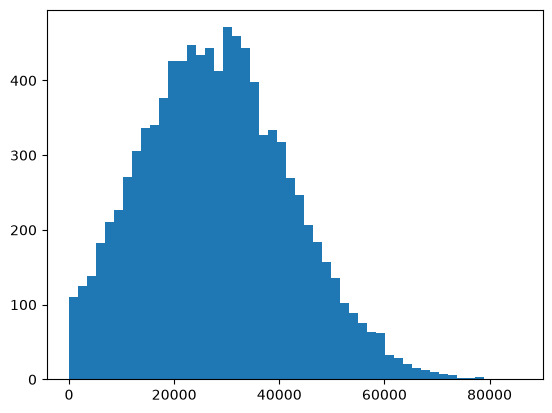

In [27]:
show_with_reject_outliers(new_incomes, std_multiple=4)